# Results

# Viewing Results

## Perplexity

Metric that measures the uncertainty of a model's predictions. Specifically, in language models, it quantifies how well the model predicts the next word in a sequence. When a model makes a prediction, it assigns probabilities to possible next words.

Let $w_1, w_2, \dots, w_T$ be a sequence of words in the test set.
The perplexity of an $n$-gram language model is defined as:

$$
\text{Perplexity}
= \exp\left(
-\frac{1}{T}
\sum_{t=1}^{T}
\log P\!\left(
w_t \mid w_{t-(n-1)}, \dots, w_{t-1}
\right)
\right)
$$

GeeksforGeeks. (2025, July 23). Perplexity for LLM evaluation. https://www.geeksforgeeks.org/nlp/perplexity-for-llm-evaluation/ 

**Where:**

- $T$ is the total number of tokens (words) in the sentence.

- $w_t$ denotes the word at position $t$ in the sentence.

- $n$ is the order of the N-gram model (e.g., $n = 1$ for a unigram model, $n = 2$ for a bigram model).

- $(w_{t-n+1}, \ldots, w_{t-1})$ represents the $(n-1)$-word context preceding the word $w_t$.

- $P(w_t \mid w_{t-n+1}, \ldots, w_{t-1})$ is the conditional probability assigned by the N-gram model to the word $w_t$ given its preceding context.

- $\sum_{t=1}^{T}$ indicates that the log-probabilities are summed over all word positions in the sentence.

- $\log(\cdot)$ is used to convert the product of probabilities into a sum, which improves numerical stability and interpretability.


In [ ]:
import json
from math import log, exp 
import pandas as pd

# Function to compute the perplexity of an n-gram model on a test dataset where n is the order of the n-gram model, test_csv is the path to the CSV file containing the test n-grams, prob_dicts is a dictionary of probability models for different n values, and epsilon is a small value to avoid log(0)

def compute_perplexity(test_csv, prob_dicts, n, epsilon=1e-12):
    df = pd.read_csv(test_csv)
    log_prob_sum = 0.0
    T = 0

    model = prob_dicts[n]

    for ngram_str in df["N-gram"]:
        ngram = eval(ngram_str)  # ['w1','w2',...]
        target = ngram[-1]

        if n == 1:
            context = "()"
        else:
            context = str(tuple(ngram[:-1]))

        prob = model.get(context, {}).get(target, epsilon)

        log_prob_sum += log(prob)
        T += 1

    return exp(-log_prob_sum / T)


def load_probability_model(path):
    with open(path, "r", encoding="utf-8") as f:
        model = json.load(f)
    return model

In [43]:
modeltype = "word"	# "word", "character"
category ="all"	# "business", "entertainment", "politics", "sport", "tech", "all"

N = [1, 2, 3, 4, 5]
prob_dicts = {}

for n in N:
    path = f"./../Probability_NGrams/{modeltype}_{n}grams_{category}_probability.json"
    prob_dicts[n] = load_probability_model(path)

perplexities = []

for n in N:
    test_file = f"./../Dataset_NGrams/bbc_word_{n}grams_test.csv"
    ppl = compute_perplexity(test_file, prob_dicts, n)
    perplexities.append(ppl)

perplexities

[1769.073119192971,
 11480.194339482558,
 4144823.409812207,
 153982042.26823324,
 554729288.0715431]

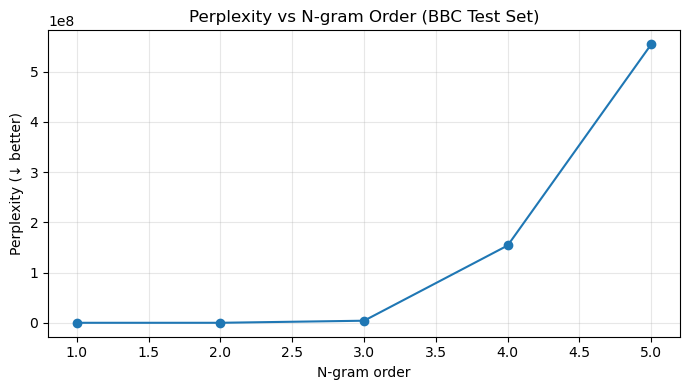

In [44]:
import matplotlib.pyplot as plt

N = [1, 2, 3, 4, 5]

plt.figure(figsize=(7, 4))
plt.plot(N, perplexities, marker="o")
plt.xlabel("N-gram order")
plt.ylabel("Perplexity (↓ better)")
plt.title("Perplexity vs N-gram Order (BBC Test Set)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

As the N-gram order increases, perplexity rises sharply. This behavior is expected due to data sparsity: higher-order N-gram models rely on increasingly specific contexts, many of which do not appear in the training data. As a result, the model assigns very low probabilities to test sequences, leading to large perplexity values. Without smoothing or backoff techniques, higher-order models tend to generalize poorly to unseen data despite being more expressive.

## N-gram Accuracy

For each N-gram order, we run the model on testing sentences and measure how often the generated continuation matches the true continuation in the test set. Through this measurement we try to answer: "Does the model’s predicted next word match the actual next word in the dataset?"

$$
\text{Accuracy}_n
=
\frac{
\text{Number of correct next-word predictions}
}{
\text{Total number of predictions}
}
$$

In [ ]:
# Function to compute next-word prediction accuracy of an n-gram model on a test dataset where test_tokens is the list of tokens in the test dataset, prob_dict is the probability model for the n-gram, and n is the order of the n-gram model.

def next_word_accuracy(test_tokens, prob_dict, n):
    correct = 0
    total = 0

    for t in range(len(test_tokens)):
        # build context
        if n == 1:
            context = ()
        else:
            if t < n - 1:
                continue  # not enough context yet
            context = tuple(test_tokens[t-(n-1):t])

        # get model predictions
        if context not in prob_dict:
            continue  # model cannot predict here

        predicted_word = max(
            prob_dict[context],
            key=prob_dict[context].get
        )

        actual_word = test_tokens[t]

        if predicted_word == actual_word:
            correct += 1

        total += 1

    return correct / total if total > 0 else 0.0

In [ ]:
import pandas as pd

N = [1, 2, 3, 4, 5]

for n in N:
    print(f"\n{'='*50}")
    print(f"Evaluating {n}-gram model")
    print(f"{'='*50}")

    # Load model
    model = prob_dicts[n]

    # Generate sentence
    generated_sentence = generate_sentence(model, n)

    # Load test data
    test_df = pd.read_csv(f"./../Dataset_NGrams/bbc_word_{n}grams_test.csv")
    reference_ngrams = test_df["N-gram"].tolist()

    # Reconstruct one reference sentence (take first few n-grams)
    reference_sentence = reconstruct_sentence_from_ngrams(reference_ngrams[:10])

    # Compute accuracy
    score = ngram_accuracy_score(
        generated_sentence,
        reference_ngrams,
        n
    )

    # Print results
    print("Generated sentence:")
    print(" ".join(generated_sentence))

    print("\nReference sentence:")
    print(" ".join(reference_sentence))

    print(f"\nN-gram accuracy score: {score:.4f}")

Perplexity evaluates how well an N-gram model predicts the test data, while N-gram overlap measures how closely generated sequences resemble the empirical N-grams in the dataset. Lower perplexity indicates better generalization, whereas higher overlap reflects closer adherence to observed linguistic patterns.